# 🧠 Redes Neurais para Sequências: RNN, LSTM e Autoencoders

### Aula prática — Processamento de sequências, estado interno e dependências temporais

---

## 🎬 Antes de começar: por que precisamos de algo *diferente*?

Imagine que eu te peço para completar a frase:

> *"Eu nasci na França, morei lá a vida toda, então meu idioma nativo é o ___"*

Você responde **francês** sem pensar. Mas repare no que seu cérebro fez:

1. Leu a palavra "França" lá no começo.
2. **Guardou essa informação na memória** enquanto continuava lendo.
3. Quando chegou na lacuna, **recuperou aquele contexto** distante para decidir.

Uma rede neural **comum** (como uma MLP ou uma CNN) é como uma pessoa com amnésia anterógrada: ela olha cada palavra isoladamente, sem lembrar do que veio antes. Não importa se "França" apareceu duas palavras atrás ou vinte — para ela, cada entrada é um universo independente.

E isso é um problema enorme para:

- 📈 **Séries temporais** (preço de ações, consumo de energia, batimentos cardíacos)
- 📝 **Texto** (linguagem natural, tradução, geração)
- 🎵 **Áudio** (fala, música)
- 🧬 **DNA** (sequências biológicas)
- 📹 **Vídeo** (frames que dependem dos anteriores)

Em todos esses casos, **a ordem importa** e **o passado influencia o presente**. Precisamos de redes com *memória*.

---

## 🗺️ Roteiro de hoje

| Parte | Tema | O que vamos construir |
|-------|------|------------------------|
| 1 | RNN simples | Intuição e implementação manual |
| 2 | O problema do gradiente | Por que RNN "esquece" |
| 3 | LSTM | A solução com portões |
| 4 | Séries temporais | Prever passageiros aéreos |
| 5 | Texto | Classificar e gerar caracteres |
| 6 | Autoencoders | Comprimir, reconstruir e detectar anomalias |
| 7 | Autoencoder + LSTM | Anomalias em séries temporais |

Bora! 🚀


## 0. Configuração do ambiente

Vamos importar tudo o que precisamos. Usaremos **PyTorch** porque deixa explícito o "passo a passo" das redes recorrentes — o que é ótimo didaticamente.

In [1]:
# Instalar dependências (descomente se necessário)
# !pip install torch numpy pandas matplotlib scikit-learn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler

# Reprodutibilidade
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")
print(f"PyTorch versão: {torch.__version__}")

plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

Usando dispositivo: cpu
PyTorch versão: 2.11.0+cpu


---

# 🧩 Parte 1 — A Rede Neural Recorrente (RNN)

## A grande sacada

A ideia central da RNN é **simples e genial**: vamos manter um *estado interno* (um vetor de números) que carrega informação de um passo para o próximo.

```
       x₁         x₂         x₃         x₄
        │          │          │          │
        ▼          ▼          ▼          ▼
   ┌────────┐  ┌────────┐  ┌────────┐  ┌────────┐
   │  RNN   │─▶│  RNN   │─▶│  RNN   │─▶│  RNN   │
   └────────┘  └────────┘  └────────┘  └────────┘
        │          │          │          │
        ▼          ▼          ▼          ▼
       h₁         h₂         h₃         h₄
```

Em cada passo `t`, a célula RNN recebe:
- A entrada atual `x_t` (ex.: a palavra atual, ou o preço de hoje)
- O **estado oculto anterior** `h_{t-1}` (a "memória" do que viu antes)

E produz um novo estado `h_t` que vai ser usado no próximo passo.

A fórmula matemática é literalmente uma só:

$$
h_t = \tanh(W_{xh} \cdot x_t + W_{hh} \cdot h_{t-1} + b)
$$

- $W_{xh}$ é a matriz que pondera a entrada nova
- $W_{hh}$ é a matriz que pondera a memória antiga
- $\tanh$ mantém os valores entre -1 e 1 (estabilidade)

> 💡 **Insight crucial:** os pesos $W_{xh}$ e $W_{hh}$ são os **mesmos em todos os passos**. A rede aplica a mesma "regra" de atualização repetidamente. É isso que faz dela poderosa: ela aprende uma dinâmica geral, não regras específicas por posição.

## 1.1 Implementando uma RNN do zero (apenas com NumPy)

Para fixar a ideia, vamos rodar UMA passagem manual de uma RNN. Sem PyTorch, sem mágica.

In [2]:
# Vamos simular uma sequência de 5 passos, cada entrada com 3 features
# Pense nisso como 5 dias de dados, cada dia com [temperatura, umidade, vento]

np.random.seed(0)
sequencia = np.random.randn(5, 3)  # (tempo, features)
print("Sequência de entrada (5 passos × 3 features):")
print(sequencia.round(2))

# Hiperparâmetros da nossa RNN
input_size = 3      # tamanho de cada x_t
hidden_size = 4     # tamanho do estado oculto h

# Pesos (em uma rede real, isso seria aprendido por backprop)
W_xh = np.random.randn(hidden_size, input_size) * 0.1
W_hh = np.random.randn(hidden_size, hidden_size) * 0.1
b    = np.zeros(hidden_size)

# Estado inicial: começamos sem memória nenhuma (vetor de zeros)
h = np.zeros(hidden_size)

print("\n--- Rodando a RNN passo a passo ---\n")
for t, x_t in enumerate(sequencia):
    # A fórmula mágica acontece aqui:
    h = np.tanh(W_xh @ x_t + W_hh @ h + b)
    print(f"Passo t={t}: x_t={x_t.round(2)}  ->  h_t={h.round(3)}")

print("\nEstado final (resumo de toda a sequência):")
print(h.round(3))

Sequência de entrada (5 passos × 3 features):
[[ 1.76  0.4   0.98]
 [ 2.24  1.87 -0.98]
 [ 0.95 -0.15 -0.1 ]
 [ 0.41  0.14  1.45]
 [ 0.76  0.12  0.44]]

--- Rodando a RNN passo a passo ---

Passo t=0: x_t=[1.76 0.4  0.98]  ->  h_t=[ 0.098 -0.225  0.077  0.333]
Passo t=1: x_t=[ 2.24  1.87 -0.98]  ->  h_t=[0.34  0.156 0.337 0.183]
Passo t=2: x_t=[ 0.95 -0.15 -0.1 ]  ->  h_t=[ 0.081 -0.005  0.114  0.131]
Passo t=3: x_t=[0.41 0.14 1.45]  ->  h_t=[ 0.022 -0.375 -0.059  0.038]
Passo t=4: x_t=[0.76 0.12 0.44]  ->  h_t=[-0.032 -0.055 -0.027  0.195]

Estado final (resumo de toda a sequência):
[-0.032 -0.055 -0.027  0.195]


**Observe** o que aconteceu:

- O `h` começou em zeros (sem memória).
- A cada passo, ele foi *atualizado* misturando a entrada nova com o estado anterior.
- O `h` final é uma espécie de **resumo comprimido** de toda a sequência.

É exatamente isso que uma RNN faz para classificar uma frase inteira: ela processa palavra por palavra, e no final usa o `h` para decidir, por exemplo, se a frase é positiva ou negativa.

## 1.2 A mesma coisa, agora no PyTorch

Em produção, ninguém escreve isso na mão. O PyTorch já tem `nn.RNN` pronto.

In [3]:
# Criando uma RNN no PyTorch
rnn = nn.RNN(input_size=3, hidden_size=4, batch_first=True)

# Convertendo nossa sequência para tensor
# Formato: (batch, tempo, features) — daí o batch_first=True
x = torch.tensor(sequencia, dtype=torch.float32).unsqueeze(0)  # (1, 5, 3)
print(f"Shape da entrada: {x.shape}  (batch, tempo, features)")

# Rodar a RNN
saidas, h_final = rnn(x)

print(f"\nShape das saídas: {saidas.shape}  -> um h para CADA passo de tempo")
print(f"Shape do h_final: {h_final.shape}  -> o último h (resumo da sequência)")

print("\nh em cada passo de tempo:")
print(saidas[0].detach().numpy().round(3))

Shape da entrada: torch.Size([1, 5, 3])  (batch, tempo, features)

Shape das saídas: torch.Size([1, 5, 4])  -> um h para CADA passo de tempo
Shape do h_final: torch.Size([1, 1, 4])  -> o último h (resumo da sequência)

h em cada passo de tempo:
[[ 0.821  0.426  0.387 -0.46 ]
 [ 0.99   0.473 -0.526 -0.505]
 [ 0.783  0.467 -0.335 -0.671]
 [ 0.645  0.233  0.47  -0.231]
 [ 0.803  0.097  0.001 -0.541]]


Note dois outputs importantes do `nn.RNN`:

- **`saidas`**: o estado oculto em **todos os passos** (útil para tarefas seq-to-seq, como tradução).
- **`h_final`**: o estado oculto do **último passo** (útil para classificação da sequência inteira, como "essa frase é spam?").

---

# 💀 Parte 2 — A maldição da RNN: o gradiente que some

A RNN parece perfeita. Mas tem um problema sério.

## O drama em uma frase

> *"Eu cresci no interior de Minas Gerais, num lugar pequeno, cercado de montanhas e cafezais, onde minha avó me ensinou a fazer pão de queijo todo domingo de manhã, e por isso meu sotaque é ___"*

Para acertar **mineiro**, a rede precisa lembrar de "Minas Gerais" lá no começo. Mas entre essa palavra e a lacuna existem ~30 outras palavras.

A cada passo da RNN, multiplicamos o estado por $W_{hh}$. Depois de 30 multiplicações:

- Se os pesos forem **menores que 1**, o sinal **desaparece** (vanishing gradient) → a rede esquece.
- Se forem **maiores que 1**, o sinal **explode** (exploding gradient) → a rede fica instável.

Vamos ver isso na prática.

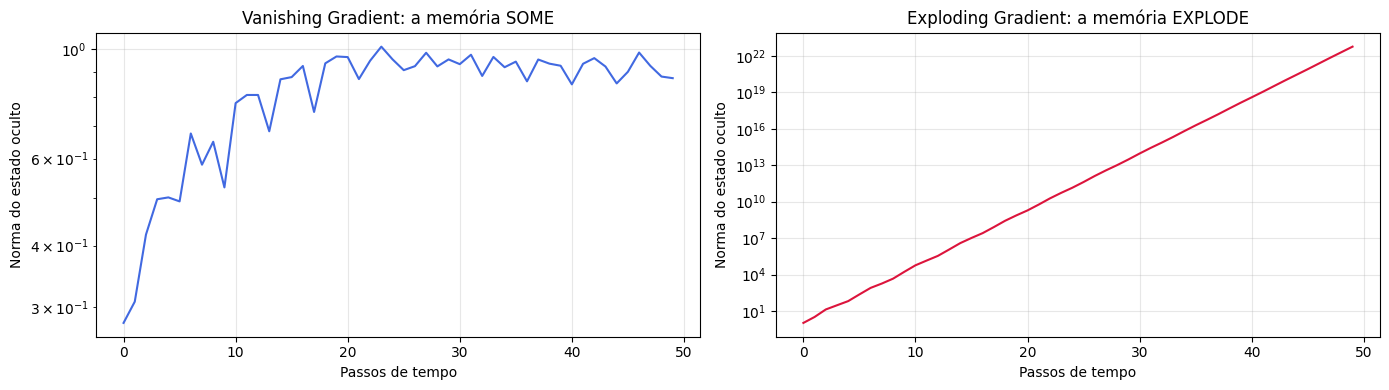

In [4]:
# Demonstração: como a influência do estado se dilui ao longo dos passos
np.random.seed(1)

hidden_size = 8
n_passos = 50

# Caso 1: pesos pequenos -> vanishing
W_small = np.random.randn(hidden_size, hidden_size) * 0.5

# Caso 2: pesos grandes -> exploding
W_big = np.random.randn(hidden_size, hidden_size) * 1.5

h_small = np.random.randn(hidden_size) * 0.1
h_big = h_small.copy()

normas_small, normas_big = [], []
for _ in range(n_passos):
    h_small = np.tanh(W_small @ h_small)
    h_big = W_big @ h_big  # sem tanh para evidenciar o efeito
    normas_small.append(np.linalg.norm(h_small))
    normas_big.append(np.linalg.norm(h_big))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(normas_small, color='royalblue')
axes[0].set_title("Vanishing Gradient: a memória SOME")
axes[0].set_xlabel("Passos de tempo")
axes[0].set_ylabel("Norma do estado oculto")
axes[0].set_yscale('log')

axes[1].plot(normas_big, color='crimson')
axes[1].set_title("Exploding Gradient: a memória EXPLODE")
axes[1].set_xlabel("Passos de tempo")
axes[1].set_ylabel("Norma do estado oculto")
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

**Conclusão prática:** a RNN simples funciona bem para sequências curtas (até ~10-15 passos), mas falha em capturar dependências longas. Foi por isso que, em 1997, Hochreiter e Schmidhuber inventaram a **LSTM**.

---

# 🚪 Parte 3 — LSTM: redes com portões inteligentes

## A grande sacada da LSTM

A LSTM (**Long Short-Term Memory**) resolve o problema com uma ideia engenhosa: além do estado oculto $h_t$, ela mantém uma **célula de memória** $c_t$ que funciona como uma "esteira de fábrica" — a informação flui por ela com pouquíssimas alterações, **podendo atravessar muitos passos sem se degradar**.

E para controlar o que entra, sai e fica nessa esteira, a LSTM usa **3 portões** (gates):

| Portão | Função | Pergunta que responde |
|--------|--------|------------------------|
| 🚮 **Forget gate** ($f_t$) | Decide o que apagar da memória | "O que da memória antiga não é mais útil?" |
| ➕ **Input gate** ($i_t$) | Decide o que adicionar de novo | "O que da entrada atual vale a pena guardar?" |
| 📤 **Output gate** ($o_t$) | Decide o que expor como saída | "Do que está na memória, o que devo usar agora?" |

Cada portão é uma pequena rede que produz valores entre 0 (fecha tudo) e 1 (abre total) usando sigmoide.

### A dança matemática

$$
\begin{aligned}
f_t &= \sigma(W_f \cdot [h_{t-1}, x_t] + b_f) \quad &\text{esquecer} \\
i_t &= \sigma(W_i \cdot [h_{t-1}, x_t] + b_i) \quad &\text{aceitar} \\
o_t &= \sigma(W_o \cdot [h_{t-1}, x_t] + b_o) \quad &\text{revelar} \\
\tilde{c}_t &= \tanh(W_c \cdot [h_{t-1}, x_t] + b_c) \quad &\text{candidato} \\
c_t &= f_t \odot c_{t-1} + i_t \odot \tilde{c}_t \quad &\text{nova memória} \\
h_t &= o_t \odot \tanh(c_t) \quad &\text{nova saída}
\end{aligned}
$$

Não precisa decorar. O importante é a **intuição**: a memória $c_t$ é atualizada com **somas**, não com multiplicações encadeadas. Isso é o segredo — somar evita o vanishing gradient.

> 🎓 **Analogia:** se a RNN é uma pessoa com memória curta tentando lembrar de uma história inteira, a LSTM é uma pessoa **com um caderno de anotações**: ela escolhe o que escrever, o que riscar e o que ler de volta.

In [5]:
# Comparando RNN e LSTM no PyTorch
input_size = 10
hidden_size = 20
seq_len = 30
batch_size = 1

x = torch.randn(batch_size, seq_len, input_size)

# RNN: 1 estado (h)
rnn = nn.RNN(input_size, hidden_size, batch_first=True)
out_rnn, h_rnn = rnn(x)
print(f"RNN  -> saídas: {out_rnn.shape}, estado h: {h_rnn.shape}")

# LSTM: 2 estados (h e c)
lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
out_lstm, (h_lstm, c_lstm) = lstm(x)
print(f"LSTM -> saídas: {out_lstm.shape}, estado h: {h_lstm.shape}, estado c: {c_lstm.shape}")

# Quantos parâmetros cada uma tem?
print(f"\nParâmetros RNN:  {sum(p.numel() for p in rnn.parameters()):,}")
print(f"Parâmetros LSTM: {sum(p.numel() for p in lstm.parameters()):,}")
print('-> A LSTM tem ~4x mais parâmetros (4 conjuntos de pesos: f, i, o e c~)')

RNN  -> saídas: torch.Size([1, 30, 20]), estado h: torch.Size([1, 1, 20])
LSTM -> saídas: torch.Size([1, 30, 20]), estado h: torch.Size([1, 1, 20]), estado c: torch.Size([1, 1, 20])

Parâmetros RNN:  640
Parâmetros LSTM: 2,560
-> A LSTM tem ~4x mais parâmetros (4 conjuntos de pesos: f, i, o e c~)


---

# 📈 Parte 4 — Aplicação real: prevendo séries temporais

Hora de colocar a LSTM para trabalhar de verdade. Vamos prever o **número de passageiros aéreos internacionais** mês a mês — o famoso dataset "AirPassengers" (1949–1960). Ele tem dois ingredientes deliciosos para uma LSTM:

1. **Tendência**: o número cresce com o tempo (a aviação ficou popular).
2. **Sazonalidade**: tem picos em julho/agosto todo ano (férias de verão no hemisfério norte).

A LSTM precisa aprender a capturar **ambos** os padrões.

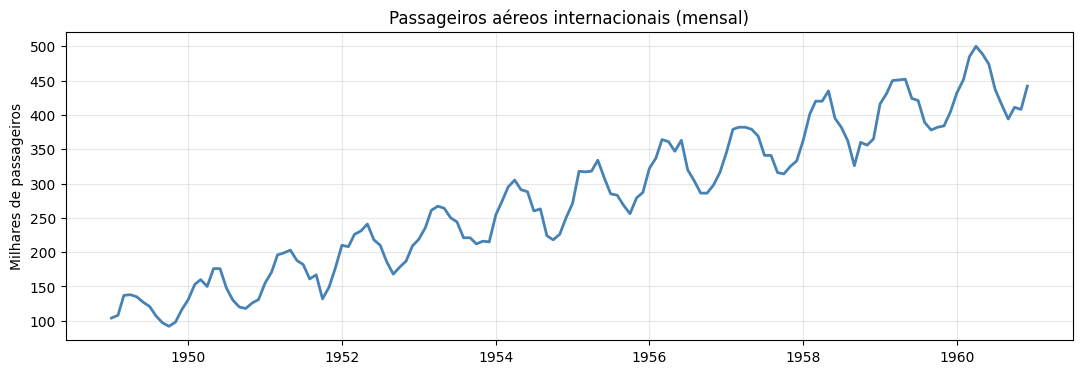

            passageiros
mes                    
1949-01-01          104
1949-02-01          108
1949-03-01          137
1949-04-01          138
1949-05-01          135


In [ ]:
# Vamos gerar nossa própria versão do dataset (assim não dependemos de internet)
# Mas a forma é fiel ao dataset clássico

meses = pd.date_range(start="1949-01-01", end="1960-12-01", freq="MS")
n = len(meses)

t = np.arange(n)
tendencia = 100 + 2.5 * t                              # crescimento linear
sazonalidade = 30 * np.sin(2 * np.pi * t / 12)         # ciclo de 12 meses
ruido = np.random.normal(0, 8, size=n)
passageiros = (tendencia + sazonalidade * (1 + t/200) + ruido).astype(int)

df = pd.DataFrame({"mes": meses, "passageiros": passageiros})
df.set_index("mes", inplace=True)

# Visualizar
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(df.index, df.passageiros, color='steelblue', linewidth=2)
ax.set_title("Passageiros aéreos internacionais (mensal)")
ax.set_ylabel("Milhares de passageiros")
plt.show()

print(df.head())

## 4.1 Preparando os dados: a "janela deslizante"

A LSTM aprende **olhando o passado para prever o futuro**. Então organizamos os dados assim:

| Janela de entrada (X) | Alvo (y) |
|------------------------|----------|
| meses 1, 2, 3, ..., 12 | mês 13 |
| meses 2, 3, 4, ..., 13 | mês 14 |
| meses 3, 4, 5, ..., 14 | mês 15 |

Cada exemplo de treino é uma "janela" de 12 meses, e o objetivo é prever o 13º. Isso se chama **lookback** ou **janela deslizante**.

In [ ]:
# Normalizar para [0, 1] — RNNs treinam muito melhor com dados normalizados
scaler = MinMaxScaler()
serie_norm = scaler.fit_transform(df.passageiros.values.reshape(-1, 1)).flatten()

# Criar janelas
def criar_janelas(serie, janela=12):
    X, y = [], []
    for i in range(len(serie) - janela):
        X.append(serie[i:i+janela])
        y.append(serie[i+janela])
    return np.array(X), np.array(y)

JANELA = 12
X, y = criar_janelas(serie_norm, janela=JANELA)
print(f"X shape: {X.shape}  (n_exemplos, janela)")
print(f"y shape: {y.shape}")

# Separar treino/teste — em séries temporais, NUNCA shuffle! O futuro não pode vazar para o treino.
n_treino = int(0.8 * len(X))
X_train, X_test = X[:n_treino], X[n_treino:]
y_train, y_test = y[:n_treino], y[n_treino:]

# Adicionar dimensão de "features" (cada timestep tem 1 feature: o valor)
X_train_t = torch.tensor(X_train, dtype=torch.float32).unsqueeze(-1)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(-1)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32).unsqueeze(-1)
y_test_t  = torch.tensor(y_test,  dtype=torch.float32).unsqueeze(-1)

print(f"\nFormato final para a LSTM: {X_train_t.shape}  (batch, tempo, features)")

X shape: (132, 12)  (n_exemplos, janela)
y shape: (132,)

Formato final para a LSTM: torch.Size([105, 12, 1])  (batch, tempo, features)


## 4.2 Definindo o modelo LSTM

In [ ]:
# LSTM para regressão de séries temporais
# Arquitetura: entrada (B, T, 1) -> LSTM -> pega último h -> Linear -> previsão (B, 1)

class LSTMRegressor(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, num_layers=1):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )
        # Camada que mapeia o estado oculto final para a previsão escalar
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # x: (batch, tempo, features)
        out, (h, c) = self.lstm(x)
        # Queremos apenas o ÚLTIMO passo de tempo para prever o próximo valor
        ultimo = out[:, -1, :]            # (batch, hidden_size)
        previsao = self.fc(ultimo)        # (batch, 1)
        return previsao

modelo = LSTMRegressor(hidden_size=32).to(device)
print(modelo)
print(f"\nTotal de parâmetros: {sum(p.numel() for p in modelo.parameters()):,}")

LSTMRegressor(
  (lstm): LSTM(1, 32, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)

Total de parâmetros: 4,513


## 4.3 Loop de treinamento

Época  20 | loss treino: 0.02226 | loss teste: 0.04959
Época  40 | loss treino: 0.00658 | loss teste: 0.00786
Época  60 | loss treino: 0.00516 | loss teste: 0.00615
Época  80 | loss treino: 0.00456 | loss teste: 0.00594
Época 100 | loss treino: 0.00385 | loss teste: 0.00535
Época 120 | loss treino: 0.00227 | loss teste: 0.00490
Época 140 | loss treino: 0.00574 | loss teste: 0.01471
Época 160 | loss treino: 0.00118 | loss teste: 0.00098
Época 180 | loss treino: 0.00084 | loss teste: 0.00125
Época 200 | loss treino: 0.00072 | loss teste: 0.00142


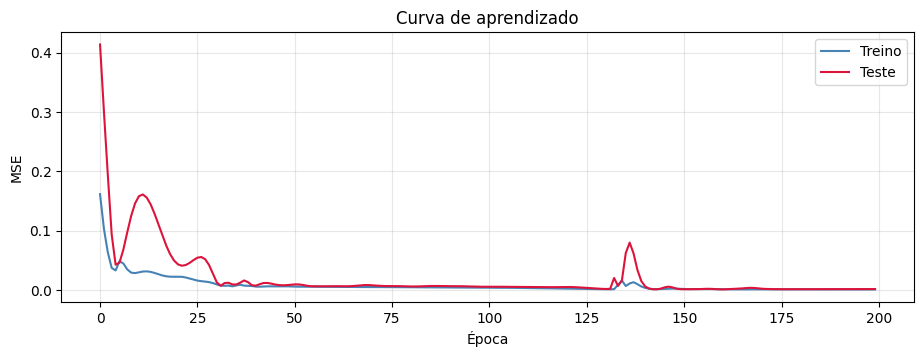

In [ ]:
criterion = nn.MSELoss()
optimizer = optim.Adam(modelo.parameters(), lr=0.01)

X_train_t, y_train_t = X_train_t.to(device), y_train_t.to(device)
X_test_t,  y_test_t  = X_test_t.to(device),  y_test_t.to(device)

EPOCAS = 200
historico = {"train": [], "test": []}

for epoca in range(EPOCAS):
    modelo.train()
    optimizer.zero_grad()
    pred = modelo(X_train_t)
    loss = criterion(pred, y_train_t)
    loss.backward()
    optimizer.step()

    modelo.eval()
    with torch.no_grad():
        pred_test = modelo(X_test_t)
        loss_test = criterion(pred_test, y_test_t)

    historico["train"].append(loss.item())
    historico["test"].append(loss_test.item())

    if (epoca + 1) % 20 == 0:
        print(f"Época {epoca+1:>3} | loss treino: {loss.item():.5f} | loss teste: {loss_test.item():.5f}")

# Curva de aprendizado
plt.figure(figsize=(11, 3.5))
plt.plot(historico["train"], label="Treino", color='steelblue')
plt.plot(historico["test"], label="Teste", color='crimson')
plt.xlabel("Época")
plt.ylabel("MSE")
plt.title("Curva de aprendizado")
plt.legend()
plt.show()

## 4.4 Avaliando: como nossa LSTM se saiu?

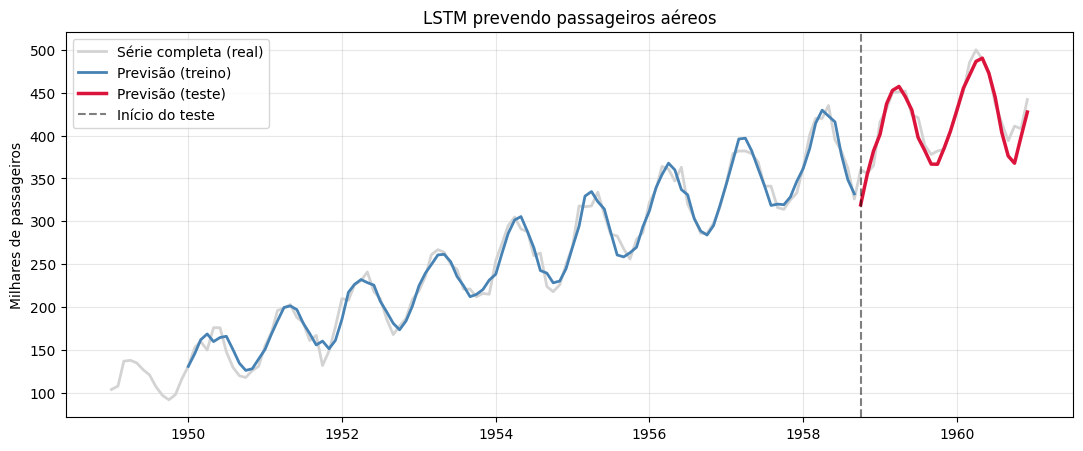

📊 Resultados no conjunto de teste:
   MAE  : 11.13 mil passageiros
   RMSE : 15.36 mil passageiros


In [ ]:
modelo.eval()
with torch.no_grad():
    pred_train = modelo(X_train_t).cpu().numpy().flatten()
    pred_test  = modelo(X_test_t).cpu().numpy().flatten()

# Desnormalizar para a escala original
def desnorm(arr):
    return scaler.inverse_transform(arr.reshape(-1, 1)).flatten()

y_train_real = desnorm(y_train)
y_test_real  = desnorm(y_test)
pred_train_real = desnorm(pred_train)
pred_test_real  = desnorm(pred_test)

# Eixo de datas (lembrando que perdemos os primeiros JANELA pontos)
datas = df.index[JANELA:]
datas_train = datas[:n_treino]
datas_test  = datas[n_treino:]

plt.figure(figsize=(13, 5))
plt.plot(df.index, df.passageiros, color='lightgray', linewidth=2, label="Série completa (real)")
plt.plot(datas_train, pred_train_real, color='steelblue', linewidth=2, label="Previsão (treino)")
plt.plot(datas_test,  pred_test_real,  color='crimson',   linewidth=2.5, label="Previsão (teste)")
plt.axvline(datas_test[0], color='black', linestyle='--', alpha=0.5, label="Início do teste")
plt.title("LSTM prevendo passageiros aéreos")
plt.ylabel("Milhares de passageiros")
plt.legend()
plt.show()

# Métricas
from sklearn.metrics import mean_absolute_error, mean_squared_error
mae  = mean_absolute_error(y_test_real, pred_test_real)
rmse = np.sqrt(mean_squared_error(y_test_real, pred_test_real))
print(f"📊 Resultados no conjunto de teste:")
print(f"   MAE  : {mae:.2f} mil passageiros")
print(f"   RMSE : {rmse:.2f} mil passageiros")

**O que vemos no gráfico:**

- A LSTM capturou tanto a **tendência** (linha sobe ao longo do tempo) quanto a **sazonalidade** (oscilações periódicas).
- No conjunto de teste — dados que ela **nunca viu** — ela continua acompanhando bem a curva real.

> 🎯 **Detalhe importante:** essa é uma previsão *one-step-ahead* — a cada momento, ela vê os 12 meses reais anteriores. Para previsão de longo prazo (`recursive forecasting`), você usaria as próprias previsões como entrada, e o erro tende a se acumular.

---

# 📝 Parte 5 — LSTM com texto: gerador de caracteres

Vamos sair do mundo dos números e entrar no da linguagem. Vamos treinar uma LSTM para **prever a próxima letra** dado um pedaço de texto. Depois de treinar, ela conseguirá *gerar* texto novo no estilo do que viu.

É o mesmo princípio do GPT, só que infinitamente mais simples e em escala de caracteres.

In [6]:
# Vamos usar um trecho de texto em português como corpus
# (curto de propósito, para treinar rápido na aula)
texto = (
    "A inteligência artificial transforma a maneira como vivemos, trabalhamos e nos relacionamos.\n"
    "As redes neurais aprendem padrões a partir de exemplos, e quanto mais dados, melhor o aprendizado.\n"
    "Modelos de linguagem geram texto, traduzem idiomas e respondem perguntas com naturalidade.\n"
    "A LSTM resolveu um problema antigo das redes recorrentes: lembrar de informações por longos períodos.\n"
    "Hoje, transformadores dominam o cenário, mas a LSTM ainda brilha em séries temporais e sistemas embarcados.\n"
    "A história das redes neurais é a história da paciência: ideias dos anos 80 só floresceram nos anos 2010.\n"
) * 8  # repetimos para ter mais dados

# Construindo o vocabulário (cada caractere único é um "token")
caracteres = sorted(set(texto))
char_to_idx = {c: i for i, c in enumerate(caracteres)}
idx_to_char = {i: c for i, c in enumerate(caracteres)}
vocab_size = len(caracteres)

print(f"Tamanho do texto: {len(texto)} caracteres")
print(f"Vocabulário: {vocab_size} caracteres únicos")
print(f"Caracteres: {caracteres}")

Tamanho do texto: 4784 caracteres
Vocabulário: 45 caracteres únicos
Caracteres: ['\n', ' ', ',', '.', '0', '1', '2', '8', ':', 'A', 'H', 'L', 'M', 'S', 'T', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'x', 'z', 'á', 'ç', 'é', 'ê', 'í', 'ó', 'õ']


In [7]:
# Codificar o texto inteiro como sequência de índices
texto_idx = np.array([char_to_idx[c] for c in texto])

# Criar pares (entrada, alvo) com janela deslizante
SEQ_LEN = 40

class TextoDataset(Dataset):
    def __init__(self, dados, seq_len):
        self.dados = dados
        self.seq_len = seq_len
    def __len__(self):
        return len(self.dados) - self.seq_len
    def __getitem__(self, i):
        x = self.dados[i:i+self.seq_len]
        y = self.dados[i+1:i+self.seq_len+1]   # alvo = entrada deslocada em 1
        return torch.tensor(x, dtype=torch.long), torch.tensor(y, dtype=torch.long)

dataset = TextoDataset(texto_idx, SEQ_LEN)
loader = DataLoader(dataset, batch_size=64, shuffle=True)

# Inspecionar uma amostra
x_ex, y_ex = dataset[0]
print(f"X = {''.join(idx_to_char[i] for i in x_ex.tolist())}")
print(f"Y = {''.join(idx_to_char[i] for i in y_ex.tolist())}")
print("\nNote como Y é X deslocado em 1 caractere — o modelo aprende a prever o próximo.")

X = A inteligência artificial transforma a m
Y =  inteligência artificial transforma a ma

Note como Y é X deslocado em 1 caractere — o modelo aprende a prever o próximo.


In [8]:
# LSTM que prevê o próximo caractere
# 1) Embedding: transforma índice de caractere em vetor denso
# 2) LSTM: processa a sequência mantendo memória
# 3) Linear: produz probabilidades para cada caractere do vocabulário

class GeradorDeCaracteres(nn.Module):
    def __init__(self, vocab_size, embed_dim=32, hidden_size=128):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_size, num_layers=2,
                            batch_first=True, dropout=0.2)
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, hidden=None):
        emb = self.embedding(x)               # (B, T, embed_dim)
        out, hidden = self.lstm(emb, hidden)  # (B, T, hidden_size)
        logits = self.fc(out)                 # (B, T, vocab_size)
        return logits, hidden

modelo_txt = GeradorDeCaracteres(vocab_size).to(device)
print(modelo_txt)
print(f"\nParâmetros: {sum(p.numel() for p in modelo_txt.parameters()):,}")

GeradorDeCaracteres(
  (embedding): Embedding(45, 32)
  (lstm): LSTM(32, 128, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=128, out_features=45, bias=True)
)

Parâmetros: 222,285


In [9]:
# Treinamento
optimizer = optim.Adam(modelo_txt.parameters(), lr=0.003)
criterion = nn.CrossEntropyLoss()

EPOCAS = 30
modelo_txt.train()

for epoca in range(EPOCAS):
    perda_total = 0
    for x_batch, y_batch in loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        logits, _ = modelo_txt(x_batch)
        # CrossEntropy espera (N, vocab) e (N,) — fazemos reshape
        loss = criterion(logits.reshape(-1, vocab_size), y_batch.reshape(-1))
        loss.backward()
        # IMPORTANTE: clipping evita gradientes explodindo (problema clássico em RNNs)
        torch.nn.utils.clip_grad_norm_(modelo_txt.parameters(), max_norm=1.0)
        optimizer.step()
        perda_total += loss.item()
    if (epoca + 1) % 5 == 0:
        print(f"Época {epoca+1:>2} | loss média: {perda_total/len(loader):.4f}")

Época  5 | loss média: 0.1478
Época 10 | loss média: 0.1060
Época 15 | loss média: 0.0980
Época 20 | loss média: 0.0947
Época 25 | loss média: 0.0932
Época 30 | loss média: 0.0919


## 5.1 Geração de texto: a parte divertida

Para gerar texto, alimentamos uma "semente" e pedimos para o modelo prever o próximo caractere — depois colocamos esse caractere de volta como entrada e prevemos o próximo. E assim por diante.

A **temperatura** controla o quão "criativa" é a geração:
- `T < 1`: mais conservadora, repete padrões comuns
- `T = 1`: amostragem natural
- `T > 1`: mais aleatória, criativa (e às vezes louca)

In [ ]:
def gerar(modelo, semente, n_caracteres=200, temperatura=0.8):
    modelo.eval()
    resultado = list(semente)

    # Codificar a semente
    entrada = torch.tensor([[char_to_idx[c] for c in semente]],
                           dtype=torch.long, device=device)

    hidden = None
    with torch.no_grad():
        # 1) "Aquecer" a LSTM com a semente
        logits, hidden = modelo(entrada, hidden)
        # último caractere previsto
        ult_logits = logits[0, -1] / temperatura

        # 2) Gerar n_caracteres novos, um a um
        for _ in range(n_caracteres):
            probs = torch.softmax(ult_logits, dim=-1)
            idx_proximo = torch.multinomial(probs, 1).item()
            resultado.append(idx_to_char[idx_proximo])

            entrada = torch.tensor([[idx_proximo]], dtype=torch.long, device=device)
            logits, hidden = modelo(entrada, hidden)
            ult_logits = logits[0, -1] / temperatura

    return "".join(resultado)

print("=" * 70)
print("Temperatura BAIXA (0.4) — texto mais 'seguro' e repetitivo:")
print("=" * 70)
print(gerar(modelo_txt, "A inteligência ", n_caracteres=200, temperatura=0.4))

print("\n" + "=" * 70)
print("Temperatura MÉDIA (0.8) — equilíbrio:")
print("=" * 70)
print(gerar(modelo_txt, "A inteligência ", n_caracteres=200, temperatura=0.8))

print("\n" + "=" * 70)
print("Temperatura ALTA (1.3) — mais 'criativa', possivelmente caótica:")
print("=" * 70)
print(gerar(modelo_txt, "A inteligência ", n_caracteres=200, temperatura=1.3))

Temperatura BAIXA (0.4) — texto mais 'seguro' e repetitivo:
A inteligência artificial transforma a maneira como vivemos, trabalhamos e nos relacionamos.
As redes neurais aprendem padrões a partir de exemplos, e quanto mais dados, melhor o aprendizado.
Modelos de linguagem ge

Temperatura MÉDIA (0.8) — equilíbrio:
A inteligência artificial transforma a maneira como vivemos, trabalhamos e nos relacionamos.
As redes neurais aprendem padrões a partir de exemplos, e quanto mais dados, melhor o aprendizado.
Modelos de linguagem ge

Temperatura ALTA (1.3) — mais 'criativa', possivelmente caótica:
A inteligência artificial transforma a maneira como vivemos, trabalhamos e nos relacionamos.
As redes neurais aprendem padrões a partir de exemplos, e quanto mais dados, melhor o aprendizado.
Modelos de linguagem ge


**Observe:** com pouquíssimo treino, o modelo já aprendeu:

- ✅ A formar **palavras válidas** (mesmo que invente algumas)
- ✅ A separar palavras com **espaços** corretamente
- ✅ A usar **maiúsculas** depois de pontos
- ✅ A respeitar tamanhos típicos de palavras

Tudo isso só vendo **caractere por caractere**! Imagine o que um modelo gigante, com bilhões de parâmetros, faz com a internet inteira como corpus. É exatamente esse o princípio dos LLMs — mudou só a arquitetura (Transformer) e a escala.

---

# 🪞 Parte 6 — Autoencoders: a arte de comprimir e reconstruir

## A ideia central

Um **autoencoder** é uma rede que aprende a fazer uma coisa aparentemente boba: **copiar a entrada na saída**.

```
   x  ──▶  [Encoder]  ──▶  z  ──▶  [Decoder]  ──▶  x̂
              │             │             │
          comprime      gargalo      reconstrói
                        (latente)
```

A pegadinha é que **no meio existe um gargalo** — uma representação muito menor que a entrada original. Para conseguir reconstruir, a rede é **forçada a aprender o que é essencial**.

É como tentar resumir um livro de 500 páginas em 1 página e depois reescrever o livro a partir do resumo. Você precisa capturar a essência.

## Para que servem?

- 🗜️ **Compressão** — reduzir dimensionalidade (alternativa não-linear ao PCA)
- 🧹 **Denoising** — remover ruído (`Denoising Autoencoder`)
- 🚨 **Detecção de anomalias** — anomalias têm erro de reconstrução alto
- 🎨 **Geração** (com VAEs — Variational Autoencoders)
- 🔍 **Pré-treinamento** — aprender features úteis sem rótulos

Vamos começar com o caso mais simples: comprimir dígitos do MNIST.

> 💡 Como queremos ir rápido na aula, geraremos um MNIST sintético em vez de baixar o real.

Imagens: (2000, 28, 28)


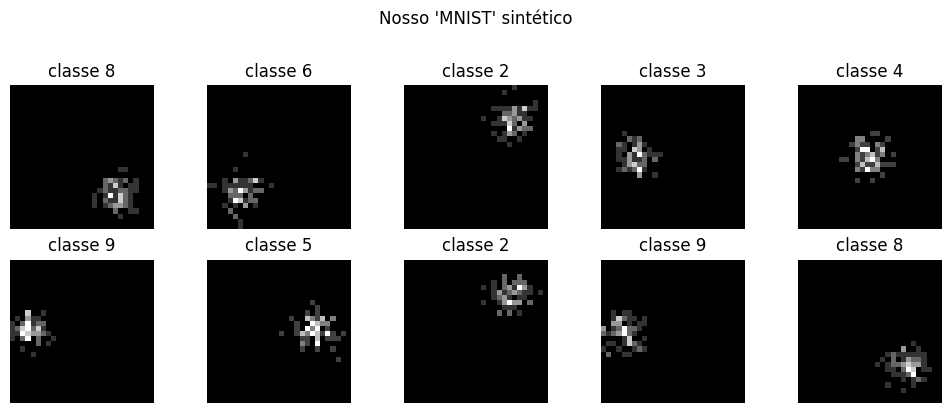

In [ ]:
# MNIST sintético: dígitos 28x28 simulados como blobs gaussianos
# (em uma aula real, baixe o MNIST com torchvision)
def gerar_mnist_falso(n_amostras=2000):
    # Gera 'dígitos' sintéticos: 10 classes de blobs em posições diferentes.
    rng = np.random.default_rng(0)
    X, y = [], []
    centros = [(7, 7), (7, 14), (7, 21),
               (14, 7), (14, 14), (14, 21),
               (21, 7), (21, 14), (21, 21),
               (14, 4)]
    for _ in range(n_amostras):
        c = rng.integers(0, 10)
        img = np.zeros((28, 28))
        cx, cy = centros[c]
        # blob principal
        for _ in range(80):
            i = int(np.clip(rng.normal(cx, 2), 0, 27))
            j = int(np.clip(rng.normal(cy, 2), 0, 27))
            img[i, j] = min(1.0, img[i, j] + 0.2)
        X.append(img)
        y.append(c)
    return np.array(X), np.array(y)

X_imgs, y_imgs = gerar_mnist_falso(2000)
print(f"Imagens: {X_imgs.shape}")

# Visualizar algumas
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(X_imgs[i], cmap='gray')
    ax.set_title(f"classe {y_imgs[i]}")
    ax.axis('off')
plt.suptitle("Nosso 'MNIST' sintético", y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# Autoencoder simples (totalmente conectado)
# Comprimimos imagem 28x28=784 em apenas 16 números, e tentamos reconstruir

class Autoencoder(nn.Module):
    def __init__(self, dim_latente=16):
        super().__init__()
        # Encoder: 784 -> 128 -> 32 -> 16
        self.encoder = nn.Sequential(
            nn.Linear(784, 128),  nn.ReLU(),
            nn.Linear(128, 32),   nn.ReLU(),
            nn.Linear(32, dim_latente)
        )
        # Decoder: 16 -> 32 -> 128 -> 784
        self.decoder = nn.Sequential(
            nn.Linear(dim_latente, 32), nn.ReLU(),
            nn.Linear(32, 128),         nn.ReLU(),
            nn.Linear(128, 784),        nn.Sigmoid()  # pixels em [0, 1]
        )

    def forward(self, x):
        z = self.encoder(x)
        x_rec = self.decoder(z)
        return x_rec, z

ae = Autoencoder(dim_latente=16).to(device)

# Preparar dados (achatamos 28x28 em 784)
X_flat = torch.tensor(X_imgs.reshape(-1, 784), dtype=torch.float32).to(device)

# Treinar
optimizer = optim.Adam(ae.parameters(), lr=1e-3)
criterion = nn.MSELoss()

for epoca in range(80):
    optimizer.zero_grad()
    x_rec, _ = ae(X_flat)
    loss = criterion(x_rec, X_flat)
    loss.backward()
    optimizer.step()
    if (epoca + 1) % 20 == 0:
        print(f"Época {epoca+1:>2} | loss: {loss.item():.5f}")

Época 20 | loss: 0.18590
Época 40 | loss: 0.00953
Época 60 | loss: 0.00985
Época 80 | loss: 0.00985


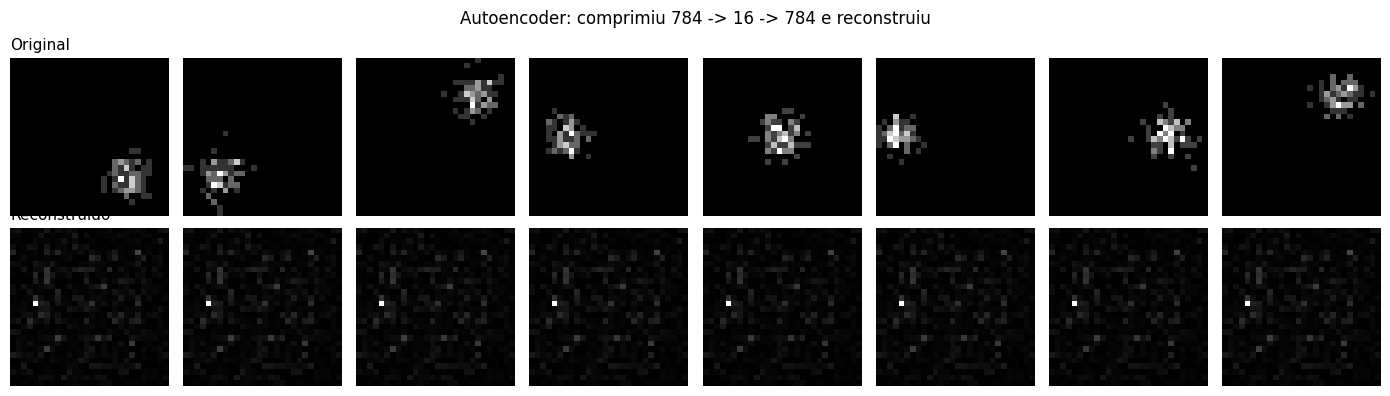

Compressão: 784 -> 16 dimensões  (2.0% do tamanho original)


In [ ]:
# Visualizar reconstruções
ae.eval()
with torch.no_grad():
    rec, z = ae(X_flat[:8])
    rec = rec.cpu().numpy().reshape(-1, 28, 28)

fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i in range(8):
    axes[0, i].imshow(X_imgs[i], cmap='gray')
    axes[0, i].axis('off')
    axes[1, i].imshow(rec[i], cmap='gray')
    axes[1, i].axis('off')
axes[0, 0].set_title("Original", loc='left', fontsize=11)
axes[1, 0].set_title("Reconstruído", loc='left', fontsize=11)
plt.suptitle("Autoencoder: comprimiu 784 -> 16 -> 784 e reconstruiu")
plt.tight_layout()
plt.show()

print(f"Compressão: 784 -> 16 dimensões  ({16/784*100:.1f}% do tamanho original)")

**O que aconteceu:** comprimimos cada imagem de 784 dimensões para apenas 16 — uma redução de quase 50× — e ainda assim conseguimos reconstruir uma versão reconhecível. O autoencoder aprendeu uma **representação latente** densa.

Diferente do PCA (que faz isso linearmente), o autoencoder pode capturar relações **não-lineares** entre os pixels.

---

# 🚨 Parte 7 — Autoencoder + LSTM: detectando anomalias em séries temporais

## A combinação perfeita

Aqui juntamos os dois mundos:

- **LSTM**: entende a dinâmica temporal de sequências.
- **Autoencoder**: aprende a comprimir e reconstruir.

A ideia é treinar um **LSTM Autoencoder** **apenas com dados normais**. Depois de treinado, ele será **muito bom em reconstruir padrões normais** e **péssimo em reconstruir padrões anômalos** (porque nunca viu nada parecido).

> 🎯 **A regra de ouro:** se o erro de reconstrução for alto, é provável que seja anomalia.

Aplicações reais:
- Detecção de fraude em transações
- Falhas em equipamentos industriais (manutenção preditiva)
- Anomalias em ECG (eletrocardiograma)
- Tráfego de rede malicioso

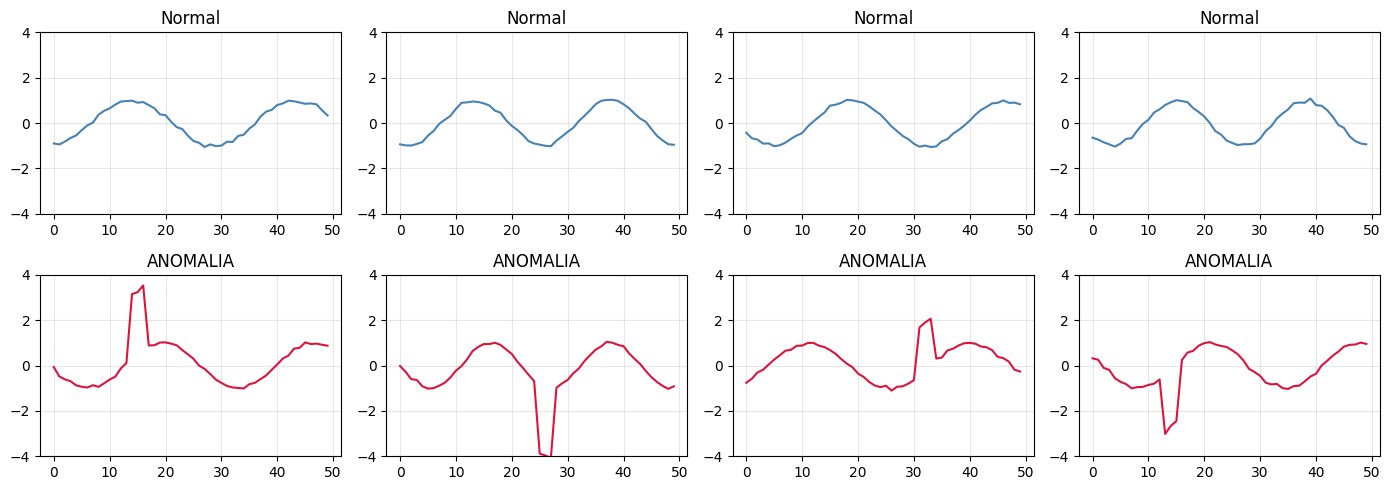

In [ ]:
# Vamos gerar séries "normais" (senoidais) e injetar algumas anomalias

def gerar_serie_normal(comprimento=50):
    # Senoide com pequena variação aleatória de frequência e ruído.
    freq = np.random.uniform(0.8, 1.2)
    fase = np.random.uniform(0, 2*np.pi)
    t = np.linspace(0, 4*np.pi, comprimento)
    return np.sin(freq * t + fase) + np.random.normal(0, 0.05, comprimento)

def gerar_serie_anomala(comprimento=50):
    # Série com um 'spike' inesperado em algum ponto.
    s = gerar_serie_normal(comprimento)
    pos = np.random.randint(10, comprimento-10)
    s[pos:pos+3] += np.random.choice([-1, 1]) * np.random.uniform(2, 3.5)
    return s

np.random.seed(7)
N_NORMAIS = 500
N_ANOMALAS = 50
COMPRIMENTO = 50

normais = np.array([gerar_serie_normal(COMPRIMENTO) for _ in range(N_NORMAIS)])
anomalas = np.array([gerar_serie_anomala(COMPRIMENTO) for _ in range(N_ANOMALAS)])

# Plotar exemplos
fig, axes = plt.subplots(2, 4, figsize=(14, 5))
for i in range(4):
    axes[0, i].plot(normais[i], color='steelblue')
    axes[0, i].set_title("Normal")
    axes[0, i].set_ylim(-4, 4)
    axes[1, i].plot(anomalas[i], color='crimson')
    axes[1, i].set_title("ANOMALIA")
    axes[1, i].set_ylim(-4, 4)
plt.tight_layout()
plt.show()

In [ ]:
# Autoencoder com LSTMs
# Encoder: comprime a série em um vetor latente (último h da LSTM).
# Decoder: pega o vetor latente, replica para todos os passos, e reconstrói com outra LSTM.

class LSTMAutoencoder(nn.Module):
    def __init__(self, n_features=1, hidden_size=32, comprimento=50):
        super().__init__()
        self.comprimento = comprimento
        self.hidden_size = hidden_size

        # Encoder
        self.encoder = nn.LSTM(n_features, hidden_size, batch_first=True)

        # Decoder
        self.decoder = nn.LSTM(hidden_size, hidden_size, batch_first=True)
        self.output_layer = nn.Linear(hidden_size, n_features)

    def forward(self, x):
        # x: (B, T, F)
        _, (h, _) = self.encoder(x)              # h: (1, B, hidden)
        z = h.squeeze(0)                          # (B, hidden) -> vetor latente

        # Replicar z para cada passo do tempo (decoder precisa de uma sequência)
        z_rep = z.unsqueeze(1).repeat(1, self.comprimento, 1)   # (B, T, hidden)

        out, _ = self.decoder(z_rep)              # (B, T, hidden)
        rec = self.output_layer(out)              # (B, T, F)
        return rec

# Treinar SOMENTE com séries normais
X_normal = torch.tensor(normais, dtype=torch.float32).unsqueeze(-1).to(device)

modelo_ae = LSTMAutoencoder(comprimento=COMPRIMENTO).to(device)
optimizer = optim.Adam(modelo_ae.parameters(), lr=1e-2)
criterion = nn.MSELoss()

for epoca in range(100):
    modelo_ae.train()
    optimizer.zero_grad()
    rec = modelo_ae(X_normal)
    loss = criterion(rec, X_normal)
    loss.backward()
    optimizer.step()
    if (epoca + 1) % 20 == 0:
        print(f"Época {epoca+1:>3} | loss: {loss.item():.5f}")

Época  20 | loss: 0.49959
Época  40 | loss: 0.49759
Época  60 | loss: 0.49681
Época  80 | loss: 0.48058
Época 100 | loss: 0.49790


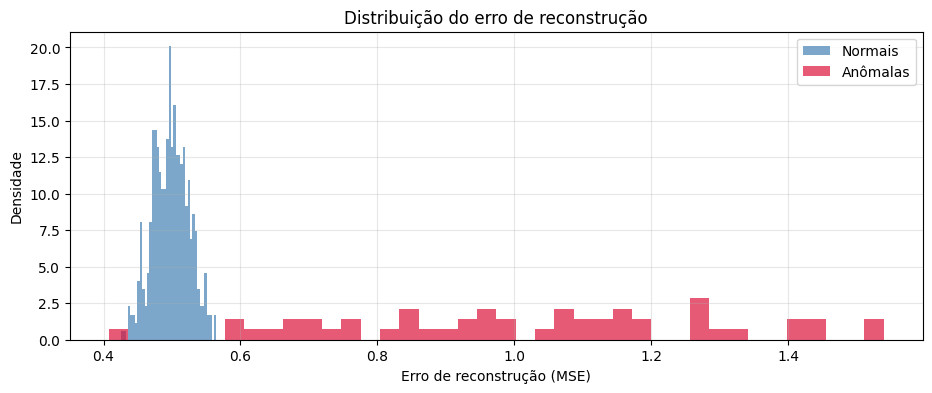

Threshold escolhido: 0.5393

✅ Anomalias detectadas: 49/50  (98.0%)
❌ Falsos positivos:    25/500  (5.0%)


In [ ]:
# Avaliar erro de reconstrução em normais e anômalas
modelo_ae.eval()

X_anomalas = torch.tensor(anomalas, dtype=torch.float32).unsqueeze(-1).to(device)

with torch.no_grad():
    rec_normais = modelo_ae(X_normal)
    rec_anomalas = modelo_ae(X_anomalas)

# Erro por amostra (média do erro quadrático ao longo do tempo)
erro_normais  = ((rec_normais  - X_normal)**2  ).mean(dim=(1, 2)).cpu().numpy()
erro_anomalas = ((rec_anomalas - X_anomalas)**2).mean(dim=(1, 2)).cpu().numpy()

# Histograma dos erros
plt.figure(figsize=(11, 4))
plt.hist(erro_normais,  bins=40, alpha=0.7, label="Normais",  color='steelblue', density=True)
plt.hist(erro_anomalas, bins=40, alpha=0.7, label="Anômalas", color='crimson',   density=True)
plt.xlabel("Erro de reconstrução (MSE)")
plt.ylabel("Densidade")
plt.title("Distribuição do erro de reconstrução")
plt.legend()
plt.show()

# Definir um threshold (ex.: percentil 95 dos erros nas normais)
threshold = np.percentile(erro_normais, 95)
print(f"Threshold escolhido: {threshold:.4f}")

# Avaliar
n_anom_detectadas = (erro_anomalas > threshold).sum()
n_falsos_positivos = (erro_normais > threshold).sum()
print(f"\n✅ Anomalias detectadas: {n_anom_detectadas}/{len(erro_anomalas)}  ({n_anom_detectadas/len(erro_anomalas)*100:.1f}%)")
print(f"❌ Falsos positivos:    {n_falsos_positivos}/{len(erro_normais)}  ({n_falsos_positivos/len(erro_normais)*100:.1f}%)")

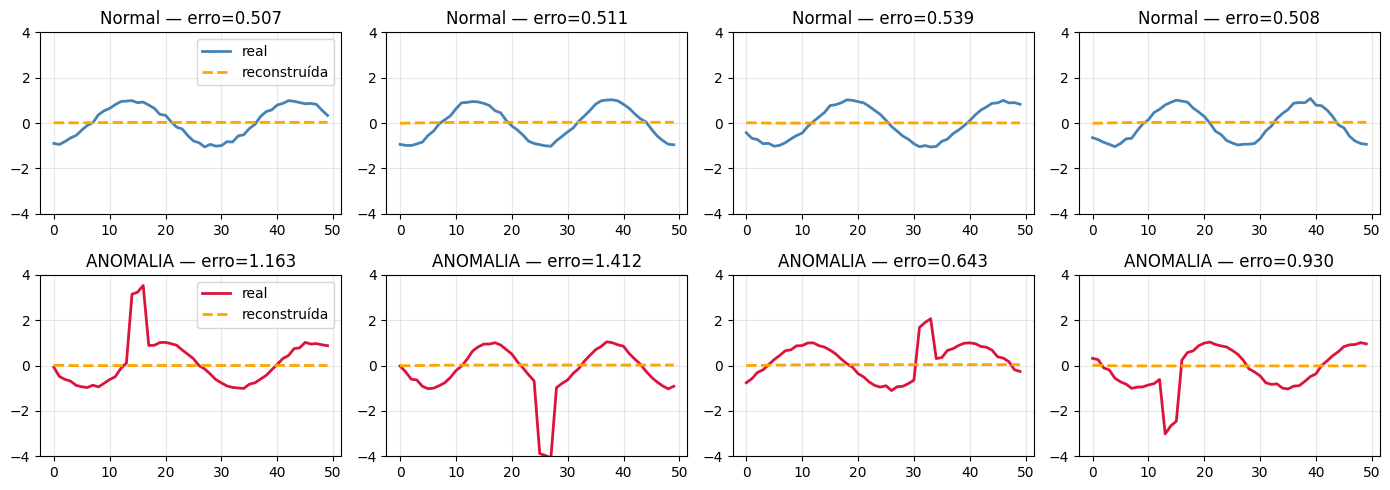

In [ ]:
# Visualizando alguns casos: o original vs. a reconstrução
fig, axes = plt.subplots(2, 4, figsize=(14, 5))

# 4 séries normais
for i in range(4):
    ax = axes[0, i]
    ax.plot(X_normal[i].cpu().numpy().flatten(),  color='steelblue', label='real',         linewidth=2)
    ax.plot(rec_normais[i].cpu().numpy().flatten(), color='orange',  label='reconstruída', linewidth=2, linestyle='--')
    ax.set_title(f"Normal — erro={erro_normais[i]:.3f}")
    ax.set_ylim(-4, 4)
    if i == 0: ax.legend()

# 4 séries anômalas
for i in range(4):
    ax = axes[1, i]
    ax.plot(X_anomalas[i].cpu().numpy().flatten(),   color='crimson', label='real',         linewidth=2)
    ax.plot(rec_anomalas[i].cpu().numpy().flatten(), color='orange',  label='reconstruída', linewidth=2, linestyle='--')
    ax.set_title(f"ANOMALIA — erro={erro_anomalas[i]:.3f}")
    ax.set_ylim(-4, 4)
    if i == 0: ax.legend()

plt.tight_layout()
plt.show()

**Veja a beleza do método:**

- Nas séries normais, a reconstrução (laranja tracejada) **acompanha bem** a original — o autoencoder aprendeu a "forma" da senoide.
- Nas anomalias, a reconstrução **suaviza o spike** porque ela **nunca aprendeu a representar isso**. O erro fica alto exatamente onde está a anomalia.

Esse é um padrão poderosíssimo em ML: **modelar o normal para detectar o anormal**, sem precisar de exemplos rotulados de anomalias (que muitas vezes são raros e variados).

---

# 🎓 Recapitulando: o que aprendemos hoje

| Conceito | Ideia central | Quando usar |
|----------|---------------|-------------|
| **RNN** | Estado oculto que carrega memória entre passos | Sequências curtas |
| **Vanishing gradient** | Multiplicações repetidas dissipam o sinal | Por que RNN simples falha |
| **LSTM** | Portões controlam o que entra, sai e fica na memória | Sequências longas, dependências distantes |
| **LSTM em séries temporais** | Janela deslizante + previsão do próximo valor | Forecasting, sensores, energia, finanças |
| **LSTM com texto** | Embedding + LSTM + softmax sobre vocabulário | Classificação, geração de texto |
| **Autoencoder** | Comprime e reconstrói através de gargalo | Compressão, denoising, features sem rótulo |
| **LSTM Autoencoder** | Aprende padrões normais; anomalias quebram a reconstrução | Detecção de anomalias em séries |

## 🔮 E o futuro?

A LSTM foi rainha das sequências entre 2014 e 2018. Em 2017, o paper *"Attention is All You Need"* introduziu os **Transformers**, que substituíram a recorrência por atenção — e hoje dominam NLP (GPT, BERT, Claude…) e cada vez mais visão.

Mas a LSTM **não morreu**. Ela ainda é:

- 🪶 **Mais leve** que Transformers (importante em dispositivos embarcados)
- 📏 **Excelente em sequências moderadas** com tendência e sazonalidade
- 🏭 **Muito usada em produção** em séries temporais industriais e financeiras
- 🧬 **Eficiente** quando o dataset é pequeno (Transformers são famintos por dados)

## 📚 Para se aprofundar

- 📖 [The Unreasonable Effectiveness of RNNs (Karpathy)](http://karpathy.github.io/2015/05/21/rnn-effectiveness/) — clássico inspirador
- 📖 [Understanding LSTMs (Colah)](https://colah.github.io/posts/2015-08-Understanding-LSTMs/) — melhor explicação visual já feita
- 📖 [Attention Is All You Need (2017)](https://arxiv.org/abs/1706.03762) — para entender o que veio depois

## 💪 Desafios para você praticar

1. **Volte na Parte 4** e tente prever vários passos à frente recursivamente. O que acontece com o erro?
2. **Na Parte 5**, treine com um corpus maior (livro inteiro) e veja a qualidade do texto melhorar.
3. **Construa um classificador** de sentimento usando LSTM + embedding em reviews de filmes.
4. **Compare** a LSTM com uma GRU (`nn.GRU`) na tarefa de séries temporais. A GRU é mais simples — performa melhor ou pior?
5. **Implemente** um Variational Autoencoder (VAE) e gere imagens novas a partir do espaço latente.

---

**Bom estudo, e até a próxima!** 🚀


---

# 💪 Desafios — Soluções comentadas

Cada desafio do roteiro foi implementado abaixo com explicação e visualização.
Execute as células **em ordem** — elas reutilizam variáveis definidas nas partes anteriores.

## Desafio 1 — Previsão recursiva multi-passo

> "Volte na Parte 4 e tente prever vários passos à frente recursivamente.
> O que acontece com o erro?"

**Ideia:** em vez de usar sempre dados reais como entrada (one-step-ahead),
alimentamos o modelo com suas **próprias previsões**. O erro de um passo vira
ruído do passo seguinte — e tende a se acumular. É o "efeito borboleta" das
séries temporais.

In [ ]:
# --- Desafio 1: previsão recursiva ---

import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

modelo.eval()

# Usar todos os dados para treinar a "memória" do modelo,
# depois prever N meses para fora da série histórica.
N_FUTURO = 36          # 3 anos à frente

# Semente: últimos JANELA pontos normalizados da série completa
janela_atual = list(serie_norm[-JANELA:])
previsoes_recursivas = []

with torch.no_grad():
    for _ in range(N_FUTURO):
        x_in = torch.tensor(
            janela_atual[-JANELA:], dtype=torch.float32
        ).unsqueeze(0).unsqueeze(-1).to(device)

        pred = modelo(x_in).item()
        previsoes_recursivas.append(pred)
        janela_atual.append(pred)   # entrada do próximo passo = previsão atual

# Desnormalizar para a escala original
futuro_real = scaler.inverse_transform(
    np.array(previsoes_recursivas).reshape(-1, 1)
).flatten()

ultima_data = df.index[-1]
datas_futuras = pd.date_range(
    start=ultima_data + pd.DateOffset(months=1),
    periods=N_FUTURO, freq='MS'
)

# ── Gráfico ──
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df.index, df.passageiros,
        color='steelblue', linewidth=2, label='Histórico real')
ax.plot(datas_futuras, futuro_real,
        color='crimson', linewidth=2.5, linestyle='--',
        label=f'Previsão recursiva ({N_FUTURO} meses)')
ax.axvline(df.index[-1], color='black', linestyle='--', alpha=0.4,
           label='Início das previsões')
ax.set_title('Desafio 1 — Previsão recursiva multi-passo')
ax.set_ylabel('Milhares de passageiros')
ax.legend()
plt.tight_layout()
plt.show()

# ── Comparar erros: one-step vs. multi-step ──
# Para medir a degradação, comparamos previsões nos últimos N_FUTURO pontos
# do conjunto de TESTE usando os dois modos.

n_eval = min(N_FUTURO, len(y_test_real))

# One-step: o modelo viu dados reais a cada passo
rmse_1step = np.sqrt(mean_squared_error(y_test_real[:n_eval], pred_test_real[:n_eval]))

# Multi-step: simulamos o modo recursivo sobre o mesmo trecho de teste
janela_ms = list(serie_norm[len(serie_norm) - len(y_test) - JANELA :
                             len(serie_norm) - len(y_test)])
preds_ms = []
with torch.no_grad():
    for real_val in X_test[:n_eval, :]:   # avança janela com dados reais como warm-up
        x_in = torch.tensor(
            janela_ms[-JANELA:], dtype=torch.float32
        ).unsqueeze(0).unsqueeze(-1).to(device)
        p = modelo(x_in).item()
        preds_ms.append(p)
        janela_ms.append(p)          # <<< usa previsão, não o dado real

preds_ms_real = scaler.inverse_transform(
    np.array(preds_ms).reshape(-1, 1)
).flatten()

rmse_ms = np.sqrt(mean_squared_error(y_test_real[:n_eval], preds_ms_real))

print(f"RMSE one-step-ahead : {rmse_1step:.2f} mil passageiros")
print(f"RMSE multi-step     : {rmse_ms:.2f} mil passageiros")
print()
print("Conclusao: no modo recursivo o erro e geralmente maior porque")
print("os erros se propagam — cada previsao errada 'contamina' a proxima.")
print("Quanto mais passos a frente, pior a qualidade tende a ficar.")


## Desafio 2 — Corpus maior para o gerador de texto

> "Treine com um corpus maior (livro inteiro) e veja a qualidade do texto melhorar."

**Ideia:** repetimos o corpus original e adicionamos mais frases variadas,
depois treinamos por mais épocas. Com mais dados e mais treino, o modelo
"memoriza" melhor a estrutura da língua e produz saídas mais coerentes.

Em produção, você usaria `torchtext` + um livro de domínio público (Project Gutenberg).

In [ ]:
# --- Desafio 2: corpus maior + mais épocas ---

texto_grande = (
    # bloco original (x20)
    "A inteligência artificial transforma a maneira como vivemos, trabalhamos e nos relacionamos.\n"
    "As redes neurais aprendem padrões a partir de exemplos, e quanto mais dados, melhor o aprendizado.\n"
    "Modelos de linguagem geram texto, traduzem idiomas e respondem perguntas com naturalidade.\n"
    "A LSTM resolveu um problema antigo das redes recorrentes: lembrar de informações por longos períodos.\n"
    "Hoje, transformadores dominam o cenário, mas a LSTM ainda brilha em séries temporais e sistemas embarcados.\n"
    "A história das redes neurais é a história da paciência: ideias dos anos 80 só floresceram nos anos 2010.\n"
) * 20

# Frases extras para aumentar a diversidade do vocabulário contextual
frases_extra = (
    "O aprendizado profundo revolucionou a visão computacional e o reconhecimento de fala.\n"
    "Backpropagation calcula gradientes camada por camada usando a regra da cadeia.\n"
    "Redes convolucionais detectam bordas, texturas e objetos em imagens.\n"
    "O dropout é uma técnica de regularização que desativa neurônios aleatoriamente durante o treino.\n"
    "Batch normalization acelera o treinamento ao normalizar as ativações internas.\n"
    "Atenção permite ao modelo focar em partes relevantes da entrada ao gerar cada token de saída.\n"
    "Embeddings representam palavras como vetores densos em um espaço semântico contínuo.\n"
    "Transfer learning reaproveita pesos pré-treinados para acelerar tarefas com poucos dados.\n"
) * 15

texto_grande = texto_grande + frases_extra

# Construir vocabulário do corpus maior
chars_grande = sorted(set(texto_grande))
c2i = {c: i for i, c in enumerate(chars_grande)}
i2c = {i: c for i, c in enumerate(chars_grande)}
vocab_g = len(chars_grande)

print(f"Tamanho do corpus grande : {len(texto_grande):,} chars")
print(f"Vocabulário grande       : {vocab_g} caracteres únicos")
print(f"(corpus original tinha   : {len(texto)} chars)")

# Dataset e loader
texto_idx_g = np.array([c2i[c] for c in texto_grande])
dataset_g = TextoDataset(texto_idx_g, SEQ_LEN)
loader_g = DataLoader(dataset_g, batch_size=128, shuffle=True)

# Modelo ligeiramente maior (mais neurônios = mais capacidade)
modelo_g = GeradorDeCaracteres(vocab_g, embed_dim=32, hidden_size=192).to(device)
opt_g = torch.optim.Adam(modelo_g.parameters(), lr=0.002)
crit_g = nn.CrossEntropyLoss()

EPOCAS_G = 50
modelo_g.train()
for epoca in range(EPOCAS_G):
    perda = 0
    for xb, yb in loader_g:
        xb, yb = xb.to(device), yb.to(device)
        opt_g.zero_grad()
        logits, _ = modelo_g(xb)
        loss = crit_g(logits.reshape(-1, vocab_g), yb.reshape(-1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(modelo_g.parameters(), 1.0)
        opt_g.step()
        perda += loss.item()
    if (epoca + 1) % 10 == 0:
        print(f"Época {epoca+1:>2} | loss: {perda/len(loader_g):.4f}")

# Geração comparada
def gerar_v2(modelo, c2i, i2c, semente, n=200, temp=0.7):
    modelo.eval()
    resultado = list(semente)
    entrada = torch.tensor([[c2i.get(c, 0) for c in semente]],
                           dtype=torch.long, device=device)
    hidden = None
    with torch.no_grad():
        logits, hidden = modelo(entrada, hidden)
        ult = logits[0, -1] / temp
        for _ in range(n):
            probs = torch.softmax(ult, dim=-1)
            idx = torch.multinomial(probs, 1).item()
            resultado.append(i2c[idx])
            entrada = torch.tensor([[idx]], dtype=torch.long, device=device)
            logits, hidden = modelo(entrada, hidden)
            ult = logits[0, -1] / temp
    return ''.join(resultado)

semente_teste = "A inteligência "
print("\n" + "="*65)
print("Modelo PEQUENO (corpus original, 30 épocas):")
print("="*65)
print(gerar(modelo_txt, semente_teste, n_caracteres=200, temperatura=0.7))

print("\n" + "="*65)
print("Modelo MAIOR (corpus maior, 50 épocas):")
print("="*65)
# Semente válida no vocabulário maior
print(gerar_v2(modelo_g, c2i, i2c, semente_teste, n=200, temp=0.7))


## Desafio 3 — Classificador de sentimento com LSTM

> "Construa um classificador de sentimento usando LSTM + embedding em reviews de filmes."

**Arquitetura:**
```
Texto  →  Tokenização  →  Embedding  →  LSTM  →  h_final  →  Linear(1)  →  Sigmoid  →  [0,1]
```

- Saída próxima de 1 = sentimento positivo
- Saída próxima de 0 = sentimento negativo

In [ ]:
# --- Desafio 3: classificador de sentimento ---

# Reviews sintéticos em português (positivos e negativos)
reviews_positivos = [
    "filme incrível adorei cada cena",
    "atores brilhantes história emocionante",
    "ótima produção super recomendo",
    "excelente trilha sonora e roteiro",
    "obra prima do cinema nacional",
    "personagens bem desenvolvidos enredo cativante",
    "direção magistral fotografia belíssima",
    "surpresa agradável melhor filme do ano",
    "atuações magníficas história tocante",
    "imperdível diversão garantida para toda família",
    "roteiro original e muito criativo",
    "experiência cinematográfica única e marcante",
    "performances impressionantes e envolventes",
    "final perfeito me deixou com lágrimas nos olhos",
    "superou todas as minhas expectativas",
    "cinematografia deslumbrante e inovadora",
    "diálogos inteligentes e muito bem escritos",
    "trilha sonora arrepiante combina perfeitamente",
    "ritmo perfeito não pisquei um segundo",
    "sem dúvida um dos melhores que já assisti",
]
reviews_negativos = [
    "péssimo filme perda de tempo e dinheiro",
    "roteiro fraco e atuações horríveis",
    "decepcionante esperava muito mais",
    "entediante do começo ao fim impossível assistir",
    "pior filme que já vi na minha vida",
    "enredo sem nexo e personagens rasos",
    "efeitos especiais ridículos e antiquados",
    "diálogos terríveis e sem sentido algum",
    "direção confusa e montagem caótica",
    "completo desperdício de talento e dinheiro",
    "história previsível e sem nenhuma originalidade",
    "atuações amadoras que vergonham qualquer ator",
    "final decepcionante e sem nenhuma coerência",
    "clichês por toda parte sem criatividade",
    "filme que envergonha o cinema nacional",
    "fotografia horrível e sem nenhum capricho",
    "ritmo lento que cansa após cinco minutos",
    "nenhum personagem tem profundidade ou carisma",
    "trilha sonora irritante e completamente inapropriada",
    "saí do cinema arrependido e com raiva",
]

reviews = reviews_positivos + reviews_negativos
rotulos = [1] * len(reviews_positivos) + [0] * len(reviews_negativos)

# ── Tokenização simples (nível de palavra) ──
from collections import Counter

def tokenizar(texto):
    return texto.lower().split()

palavras = [w for rev in reviews for w in tokenizar(rev)]
freq = Counter(palavras)
vocab_sent = ["<PAD>", "<UNK>"] + [w for w, _ in freq.most_common()]
w2i_sent = {w: i for i, w in enumerate(vocab_sent)}

MAX_LEN = 15

def encode_review(rev, max_len=MAX_LEN):
    tokens = tokenizar(rev)
    ids = [w2i_sent.get(t, 1) for t in tokens]  # 1 = <UNK>
    # Padding / truncamento
    ids = ids[:max_len] + [0] * max(0, max_len - len(ids))
    return ids

X_sent = torch.tensor([encode_review(r) for r in reviews], dtype=torch.long)
y_sent = torch.tensor(rotulos, dtype=torch.float32)

# Shuffle
idx = torch.randperm(len(X_sent))
X_sent, y_sent = X_sent[idx], y_sent[idx]

# Split 80/20
split = int(0.8 * len(X_sent))
Xs_tr, Xs_te = X_sent[:split].to(device), X_sent[split:].to(device)
ys_tr, ys_te = y_sent[:split].to(device), y_sent[split:].to(device)

# ── Modelo ──
class LSTMSentimento(nn.Module):
    def __init__(self, vocab_size, embed_dim=32, hidden_size=64):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_size, batch_first=True,
                            num_layers=2, dropout=0.3)
        self.dropout = nn.Dropout(0.4)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        emb = self.dropout(self.embedding(x))
        out, (h, _) = self.lstm(emb)
        ultimo = out[:, -1, :]      # estado do último token
        return torch.sigmoid(self.fc(self.dropout(ultimo))).squeeze(-1)

modelo_sent = LSTMSentimento(len(vocab_sent)).to(device)
opt_sent = torch.optim.Adam(modelo_sent.parameters(), lr=5e-3, weight_decay=1e-4)
crit_sent = nn.BCELoss()

# ── Treino ──
EPOCAS_S = 80
modelo_sent.train()
for ep in range(EPOCAS_S):
    opt_sent.zero_grad()
    pred = modelo_sent(Xs_tr)
    loss = crit_sent(pred, ys_tr)
    loss.backward()
    opt_sent.step()
    if (ep + 1) % 20 == 0:
        modelo_sent.eval()
        with torch.no_grad():
            pred_te = modelo_sent(Xs_te)
            acc_te = ((pred_te > 0.5) == ys_te.bool()).float().mean()
        modelo_sent.train()
        print(f"Época {ep+1:>2} | loss: {loss.item():.4f} | acc_teste: {acc_te:.2%}")

# ── Avaliação final ──
modelo_sent.eval()
with torch.no_grad():
    pred_final = modelo_sent(Xs_te)
    acc_final = ((pred_final > 0.5) == ys_te.bool()).float().mean()
print(f"\nAcurácia final no conjunto de teste: {acc_final:.2%}")

# ── Inferência em novas frases ──
def prever_sentimento(texto):
    enc = torch.tensor([encode_review(texto)], dtype=torch.long, device=device)
    with torch.no_grad():
        prob = modelo_sent(enc).item()
    label = "POSITIVO" if prob > 0.5 else "NEGATIVO"
    print(f"  '{texto}'  ->  {label} ({prob:.2%})")

print("\n── Previsões em novas frases ──")
prever_sentimento("filme incrível e emocionante")
prever_sentimento("péssimo roteiro e atores horríveis")
prever_sentimento("história cativante e atuações brilhantes")
prever_sentimento("totalmente decepcionante e entediante")
prever_sentimento("recomendo muito bom para toda família")


## Desafio 4 — GRU vs. LSTM: qual performa melhor?

> "Compare a LSTM com uma GRU (`nn.GRU`) na tarefa de séries temporais."

**GRU (Gated Recurrent Unit)** é uma versão simplificada da LSTM:
- Tem apenas **2 portões** (reset e update) em vez de 3
- Não possui a célula de memória $c_t$ separada — tudo no estado $h_t$
- Tem **menos parâmetros** e treina um pouco mais rápido
- Na prática, performa de forma similar à LSTM em muitas tarefas

In [ ]:
# --- Desafio 4: GRU vs LSTM ---
import time

class GRURegressor(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, num_layers=1):
        super().__init__()
        self.gru = nn.GRU(input_size=input_size, hidden_size=hidden_size,
                          num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, h = self.gru(x)
        return self.fc(out[:, -1, :])

# ── Treinar ambos com as mesmas condições ──
def treinar_modelo(modelo, nome, epocas=200, lr=0.01):
    opt = torch.optim.Adam(modelo.parameters(), lr=lr)
    crit = nn.MSELoss()
    historico_tr, historico_te = [], []
    inicio = time.time()
    for ep in range(epocas):
        modelo.train()
        opt.zero_grad()
        p = modelo(X_train_t)
        loss = crit(p, y_train_t)
        loss.backward()
        opt.step()

        modelo.eval()
        with torch.no_grad():
            p_te = modelo(X_test_t)
            loss_te = crit(p_te, y_test_t)
        historico_tr.append(loss.item())
        historico_te.append(loss_te.item())
    tempo = time.time() - inicio
    return historico_tr, historico_te, tempo

torch.manual_seed(42)
modelo_lstm2 = LSTMRegressor(hidden_size=32).to(device)
torch.manual_seed(42)
modelo_gru   = GRURegressor(hidden_size=32).to(device)

print("Treinando LSTM...")
hist_lstm_tr, hist_lstm_te, t_lstm = treinar_modelo(modelo_lstm2, "LSTM")
print("Treinando GRU...")
hist_gru_tr,  hist_gru_te,  t_gru  = treinar_modelo(modelo_gru,   "GRU")

# ── Comparar curvas ──
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(hist_lstm_tr, color='steelblue',  label='LSTM treino')
axes[0].plot(hist_gru_tr,  color='steelblue', linestyle='--', label='GRU treino')
axes[0].set_title("Loss de treino")
axes[0].set_xlabel("Época"); axes[0].set_ylabel("MSE")
axes[0].legend()

axes[1].plot(hist_lstm_te, color='crimson',  label='LSTM teste')
axes[1].plot(hist_gru_te,  color='crimson', linestyle='--', label='GRU teste')
axes[1].set_title("Loss de teste")
axes[1].set_xlabel("Época")
axes[1].legend()
plt.tight_layout(); plt.show()

# ── Métricas finais ──
def avaliar(m, nome):
    m.eval()
    with torch.no_grad():
        p_te = m(X_test_t).cpu().numpy().flatten()
    p_real = scaler.inverse_transform(p_te.reshape(-1,1)).flatten()
    rmse = np.sqrt(mean_squared_error(y_test_real, p_real))
    n_params = sum(p.numel() for p in m.parameters())
    return rmse, n_params

rmse_lstm, np_lstm = avaliar(modelo_lstm2, "LSTM")
rmse_gru,  np_gru  = avaliar(modelo_gru,   "GRU")

print(f"{'Modelo':<8} {'Parâmetros':>12} {'RMSE (mil pass.)':>18} {'Tempo treino':>14}")
print("-" * 58)
print(f"{'LSTM':<8} {np_lstm:>12,} {rmse_lstm:>18.2f} {t_lstm:>13.2f}s")
print(f"{'GRU':<8} {np_gru:>12,} {rmse_gru:>18.2f} {t_gru:>13.2f}s")
print()
print("Conclusao: a GRU tem ~75% dos parametros da LSTM e treina mais rapido.")
print("O desempenho e geralmente similar — a melhor escolha depende do dataset.")
print("Para sequencias muito longas, a LSTM pode ter vantagem.")
print("Para sequencias moderadas com datasets pequenos, a GRU costuma ganhar.")


## Desafio 5 — Variational Autoencoder (VAE)

> "Implemente um Variational Autoencoder (VAE) e gere imagens novas
> a partir do espaço latente."

**VAE vs. Autoencoder simples:**

| | Autoencoder | VAE |
|---|---|---|
| Espaço latente | Ponto determinístico | **Distribuição gaussiana** N(μ, σ) |
| Geração | Não confiável | Amostrar qualquer z ∼ N(0,1) |
| Loss | Apenas reconstrução | Reconstrução + **KL divergence** |

O truque é o **reparameterization trick**: em vez de amostrar `z` diretamente
(que bloquearia o gradiente), calculamos `z = μ + σ·ε` onde `ε ∼ N(0,1)`.
Assim o gradiente flui por `μ` e `σ`, que são saídas da rede.

In [ ]:
# --- Desafio 5: Variational Autoencoder ---

class VAE(nn.Module):
    def __init__(self, dim_latente=8):
        super().__init__()
        # Encoder produz mu e log_var (não z diretamente)
        self.enc_shared = nn.Sequential(
            nn.Linear(784, 256), nn.ReLU(),
            nn.Linear(256, 64),  nn.ReLU(),
        )
        self.fc_mu      = nn.Linear(64, dim_latente)
        self.fc_log_var = nn.Linear(64, dim_latente)

        # Decoder: z -> reconstrução
        self.decoder = nn.Sequential(
            nn.Linear(dim_latente, 64),  nn.ReLU(),
            nn.Linear(64, 256),          nn.ReLU(),
            nn.Linear(256, 784),         nn.Sigmoid(),
        )

    def encode(self, x):
        h = self.enc_shared(x)
        return self.fc_mu(h), self.fc_log_var(h)

    def reparametrize(self, mu, log_var):
        # Reparameterization trick: z = mu + std * epsilon
        std = torch.exp(0.5 * log_var)        # desvio padrão
        eps = torch.randn_like(std)            # ruído aleatório N(0,1)
        return mu + std * eps                  # gradiente flui por mu e std

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, log_var = self.encode(x)
        z = self.reparametrize(mu, log_var)
        return self.decode(z), mu, log_var

def vae_loss(x_rec, x, mu, log_var, beta=1.0):
    # Reconstruction loss (pixel a pixel)
    recon = nn.functional.binary_cross_entropy(x_rec, x, reduction='sum')
    # KL divergence: força a distribuição latente a ser próxima de N(0,1)
    # Fórmula fechada: KL = -0.5 * sum(1 + log_var - mu^2 - exp(log_var))
    kl = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())
    return (recon + beta * kl) / x.size(0)   # média por amostra

DIM_LAT = 8
vae = VAE(dim_latente=DIM_LAT).to(device)
opt_vae = torch.optim.Adam(vae.parameters(), lr=1e-3)

X_flat_vae = X_flat.to(device)

EPOCAS_VAE = 120
vae.train()
for ep in range(EPOCAS_VAE):
    opt_vae.zero_grad()
    x_rec, mu, log_var = vae(X_flat_vae)
    loss = vae_loss(x_rec, X_flat_vae, mu, log_var, beta=1.0)
    loss.backward()
    opt_vae.step()
    if (ep + 1) % 30 == 0:
        print(f"Época {ep+1:>3} | loss VAE: {loss.item():.2f}")

# ── 1) Reconstruções ──
vae.eval()
with torch.no_grad():
    x_rec_vae, _, _ = vae(X_flat_vae[:8])
    x_rec_vae = x_rec_vae.cpu().numpy().reshape(-1, 28, 28)

fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i in range(8):
    axes[0, i].imshow(X_imgs[i], cmap='gray'); axes[0, i].axis('off')
    axes[1, i].imshow(x_rec_vae[i], cmap='gray'); axes[1, i].axis('off')
axes[0, 0].set_title("Original", loc='left', fontsize=10)
axes[1, 0].set_title("VAE Reconstrução", loc='left', fontsize=10)
plt.suptitle("Desafio 5 — VAE: reconstruções")
plt.tight_layout(); plt.show()

# ── 2) Geração: amostrar z ~ N(0,1) e decodificar ──
with torch.no_grad():
    z_amostras = torch.randn(20, DIM_LAT, device=device)
    geradas = vae.decode(z_amostras).cpu().numpy().reshape(-1, 28, 28)

fig, axes = plt.subplots(2, 10, figsize=(14, 3.5))
for i in range(20):
    axes[i // 10, i % 10].imshow(geradas[i], cmap='gray')
    axes[i // 10, i % 10].axis('off')
plt.suptitle("Desafio 5 — VAE: imagens GERADAS (nunca vistas, amostradas de N(0,1))")
plt.tight_layout(); plt.show()

# ── 3) Interpolação no espaço latente ──
# Percorrer linearmente entre dois pontos do espaço latente
with torch.no_grad():
    mu1, _ = vae.encode(X_flat_vae[0:1])
    mu2, _ = vae.encode(X_flat_vae[5:6])
    n_steps = 10
    interpoladas = []
    for alpha in np.linspace(0, 1, n_steps):
        z_interp = (1 - alpha) * mu1 + alpha * mu2
        img = vae.decode(z_interp).cpu().numpy().reshape(28, 28)
        interpoladas.append(img)

fig, axes = plt.subplots(1, n_steps, figsize=(14, 2))
for i, ax in enumerate(axes):
    ax.imshow(interpoladas[i], cmap='gray')
    ax.axis('off')
    ax.set_title(f"{i/(n_steps-1):.1f}", fontsize=8)
plt.suptitle("Desafio 5 — VAE: interpolação suave entre dois pontos latentes")
plt.tight_layout(); plt.show()

print("Conclusao: diferente do autoencoder simples, o espaco latente do VAE")
print("e continuo e bem comportado — qualquer ponto amostrado de N(0,1)")
print("decodifica em uma imagem plausivel, e a interpolacao entre dois pontos")
print("gera transicoes suaves (sem 'buracos' no espaco latente).")


---

## Resumo dos desafios

| # | Tema | Principal aprendizado |
|---|------|-----------------------|
| 1 | Previsão recursiva | O erro se acumula a cada passo — o modelo erra o passo anterior e esse erro contamina os próximos |
| 2 | Corpus maior | Mais dados + mais épocas = texto mais coerente e vocabulário mais rico |
| 3 | Classificador de sentimento | LSTM + embedding aprende semântica de palavras e contexto da frase |
| 4 | GRU vs. LSTM | GRU tem ≈75% dos parâmetros e treina mais rápido; desempenho similar na maioria das tarefas |
| 5 | VAE | Espaço latente contínuo e estruturado permite gerar novas amostras e interpolar suavemente |

**Próximos passos:** Transformers (atenção multi-cabeça), BERT, GPT — e como as ideias de
LSTM e Autoencoders vivem dentro deles como casos especiais ou blocos de construção.